# 02 · Forward Kinematics — Product of Exponentials

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/02_forward_kinematics.ipynb)

> **ManipulaPy teaching course — notebook 2 of 11.** Running robot: Franka Panda.

**Forward kinematics (FK)** answers: *given the joint angles, where is the end-effector?* In notebook 01 we learned that following one screw axis $\mathcal{S}$ for an angle $\theta$ produces a rigid-body transform $e^{[\mathcal{S}]\theta}$. A robot arm is just a **chain of screws**, so its FK is a *product of exponentials* — one factor per joint. That is the whole idea of this notebook, applied to the 7-DOF Panda.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment on Google Colab (clone the repo + install ManipulaPy). It is a **no-op when you run locally** from a clone of the repo.

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import render_tikz_file, setup_pgf, embed_pgf_fig
import numpy as np
from helpers import load_panda, HOME, N_JOINTS, joint_limits
from ManipulaPy.utils import MatrixExp6, VecTose3, adjoint_transform, TransInv
np.set_printoptions(precision=4, suppress=True)

sm, dyn = load_panda()
print("Panda loaded |", N_JOINTS, "actuated joints")

🤖 ManipulaPy v1.3.2.post1 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features


pybullet build time: Jan 29 2025 23:16:28


Panda loaded | 7 actuated joints


## 1. The forward-kinematics problem

A serial manipulator is an open chain of links connected by joints. Choosing the joint values $\theta=(\theta_1,\dots,\theta_n)$ fixes the pose of every link, including the end-effector. FK is the map

$$\theta \;\longmapsto\; T_{sb}(\theta)\in SE(3),$$

the homogeneous transform of the end-effector frame $\{b\}$ relative to the fixed space frame $\{s\}$. It is always well-defined and unique (unlike inverse kinematics in notebook 04).

## 2. The Product of Exponentials (PoE) formula

Fix the robot at its **zero configuration** $\theta=0$ and record the end-effector pose there: call it the **home configuration** $M$. Each joint $i$ has a screw axis $\mathcal{S}_i$ expressed in the space frame (built from the joint's axis direction and a point on it, exactly as in notebook 01). Then

$$T_{sb}(\theta)=e^{[\mathcal{S}_1]\theta_1}\,e^{[\mathcal{S}_2]\theta_2}\cdots e^{[\mathcal{S}_n]\theta_n}\,M.$$

Read it right-to-left: start at the home pose $M$, then apply each joint's screw motion in turn. The figure shows the structure for the Panda.

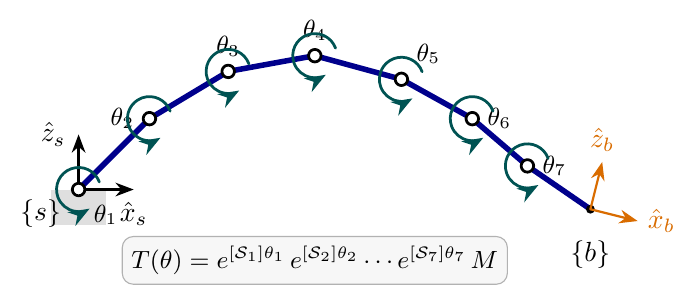

In [3]:
render_tikz_file("_figures/src/poe_chain.tex", name="poe_chain")

ManipulaPy stores the screw axes as the columns of `sm.S_list` (space frame) and `sm.B_list` (body frame), and the home configuration as `sm.M_list`. The home configuration is exactly the FK at the zero configuration:

In [4]:
M = np.array(sm.M_list)
print("home configuration M =\n", M)
assert np.allclose(sm.forward_kinematics(np.zeros(N_JOINTS)), M)
print("\nFK(0) == M :", True)

home configuration M =
 [[ 0.7071  0.7071  0.      0.088 ]
 [ 0.7071 -0.7071 -0.     -0.    ]
 [-0.      0.     -1.      0.8676]
 [ 0.      0.      0.      1.    ]]

FK(0) == M : True


## 3. The Panda's 7-vs-8 joint convention

A small but important detail. The Panda URDF has **7 revolute joints** plus a **fixed `panda_joint8` flange** (and the hand). ManipulaPy includes that fixed frame in the screw list, so `S_list` has **8 columns** even though only **7 joints actuate**. `forward_kinematics` accepts either a 7-vector (the actuated joints) or an 8-vector; the fixed flange contributes no motion. **This course always uses the 7 actuated joints** (`N_JOINTS = 7`).

In [5]:
print("S_list shape:", sm.S_list.shape, " (6 x 8: 7 revolute + 1 fixed flange)")
print("B_list shape:", sm.B_list.shape)
# Passing 7 or 8 joint values gives the same pose at the zero configuration:
T7 = sm.forward_kinematics(np.zeros(7))
T8 = sm.forward_kinematics(np.zeros(8))
print("FK(zeros7) == FK(zeros8):", np.allclose(T7, T8))

S_list shape: (6, 8)  (6 x 8: 7 revolute + 1 fixed flange)
B_list shape: (6, 8)
FK(zeros7) == FK(zeros8): True


## 4. Building the PoE product by hand

To make the formula concrete, let us evaluate it ourselves from `S_list` and `M` and check it against `forward_kinematics`. We multiply the per-joint exponentials left-to-right and post-multiply by $M$ — using the first 7 screw columns.

In [6]:
theta = HOME.copy()
S = np.array(sm.S_list)[:, :N_JOINTS]      # 6 x 7 actuated screw axes

T = np.eye(4)
for i in range(N_JOINTS):
    T = T @ MatrixExp6(VecTose3(S[:, i] * theta[i]))
T = T @ M                                  # post-multiply by the home pose

T_fk = sm.forward_kinematics(theta, frame='space')
print("hand-built PoE =\n", T)
print("\nmatches forward_kinematics(space):", np.allclose(T, T_fk))
assert np.allclose(T, T_fk)

hand-built PoE =
 [[ 1.      0.0004  0.      0.4649]
 [ 0.0004 -1.     -0.     -0.    ]
 [-0.      0.     -1.      0.5262]
 [ 0.      0.      0.      1.    ]]

matches forward_kinematics(space): True


## 5. Space frame vs body frame

The PoE formula has a twin. The **space form** above uses space-frame screws $\mathcal{S}_i$ and post-multiplies $M$. The **body form** uses body-frame screws $\mathcal{B}_i$ and *pre*-multiplies $M$:

$$T_{sb}(\theta)=M\,e^{[\mathcal{B}_1]\theta_1}\cdots e^{[\mathcal{B}_n]\theta_n}.$$

The two describe the **same** physical pose. The screw sets are related by the adjoint of the home configuration (from notebook 01), $\mathcal{B}_i=[\mathrm{Ad}_{M^{-1}}]\,\mathcal{S}_i$. ManipulaPy selects the form via the `frame` argument.

In [7]:
T_space = sm.forward_kinematics(HOME, frame='space')
T_body  = sm.forward_kinematics(HOME, frame='body')
print("space form ee position:", T_space[:3, 3])
print("body  form ee position:", T_body[:3, 3])
print("same pose:", np.allclose(T_space, T_body))

# Verify the adjoint relation B_i = Ad_{M^-1} S_i for the actuated joints.
Ad_Minv = adjoint_transform(TransInv(M))
B = np.array(sm.B_list)[:, :N_JOINTS]
assert np.allclose(Ad_Minv @ S, B, atol=1e-6)
print("B_i == Ad_{M^-1} S_i :", True)

space form ee position: [ 0.4649 -0.      0.5262]
body  form ee position: [ 0.4649 -0.      0.5262]
same pose: True
B_i == Ad_{M^-1} S_i : True


## 6. Using forward kinematics

With FK in hand we can trace where the end-effector goes as the robot moves. Below we sweep joint 1 across its range and plot the end-effector's $x$–$y$ path (the arm swings about the base axis), rendered with the TikZ/PGF backend.

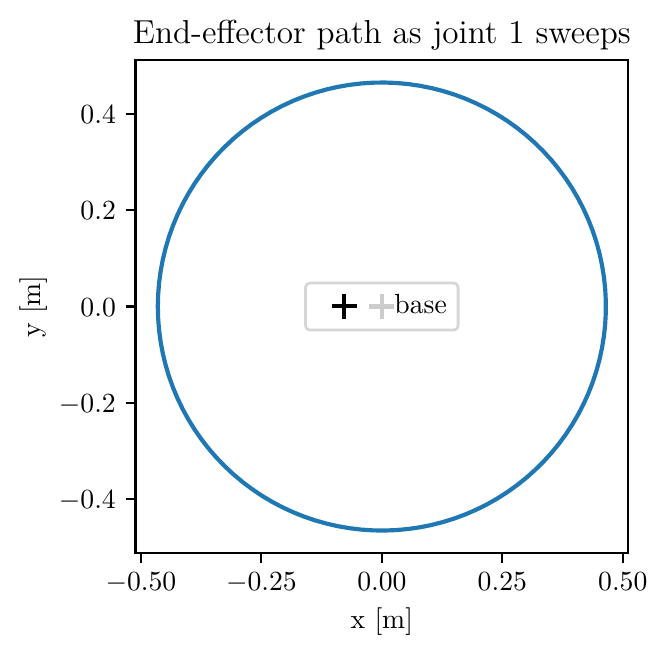

In [8]:
plt = setup_pgf()
q = HOME.copy()
angles = np.linspace(-np.pi, np.pi, 120)
xy = []
for a in angles:
    q[0] = a
    xy.append(sm.forward_kinematics(q)[:2, 3])
xy = np.array(xy)

fig, ax = plt.subplots()
ax.plot(xy[:, 0], xy[:, 1], color='tab:blue')
ax.scatter([0], [0], color='black', marker='+', s=80, label='base')
ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('End-effector path as joint 1 sweeps'); ax.legend()
embed_pgf_fig(fig, name="fk_joint1_sweep")

## 7. Visualizing the robot

The Product-of-Exponentials math is easier to trust when you can *see* the arm. ManipulaPy's **URDF module** exposes the full kinematic structure through `robot.link_fk`, which returns the world frame of every link at a given configuration — **no mesh files and no GUI**, so it renders headless (and on Colab). We use it to draw the Panda as a 3D stick figure at several configurations.

*(The mesh-based PyBullet simulator is covered in notebook 09; it needs the Franka mesh package, which isn't bundled with ManipulaPy, so we visualize from the kinematic structure here.)*

In [9]:
from ManipulaPy.urdf_processor import URDFToSerialManipulator
from helpers import PANDA_URDF

# The URDF module gives every link's world frame via link_fk (mesh-free, headless).
_robot = URDFToSerialManipulator(PANDA_URDF).robot
_arm = [j.name for j in _robot.actuated_joints][:N_JOINTS]
_chain = ["panda_link0", "panda_link1", "panda_link2", "panda_link3", "panda_link4",
          "panda_link5", "panda_link6", "panda_link7", "panda_link8", "panda_hand"]

def link_points(q):
    '''World positions of the main-chain link frames at config q (7-vector).'''
    lfk = _robot.link_fk(cfg={n: float(q[i]) for i, n in enumerate(_arm)})
    name2T = {getattr(L, "name", str(L)): T for L, T in lfk.items()}
    return np.array([name2T[n][:3, 3] for n in _chain if n in name2T])

# Cross-check: the URDF module's fingertip frame agrees with SerialManipulator FK.
_lfk = _robot.link_fk(cfg={n: float(HOME[i]) for i, n in enumerate(_arm)})
_name2T = {getattr(L, "name", str(L)): T for L, T in _lfk.items()}
assert np.allclose(_name2T["panda_leftfinger"][:3, 3],
                   sm.forward_kinematics(HOME)[:3, 3], atol=1e-6)
print("URDF link_fk agrees with forward_kinematics at the end-effector :", True)

URDF link_fk agrees with forward_kinematics at the end-effector : True


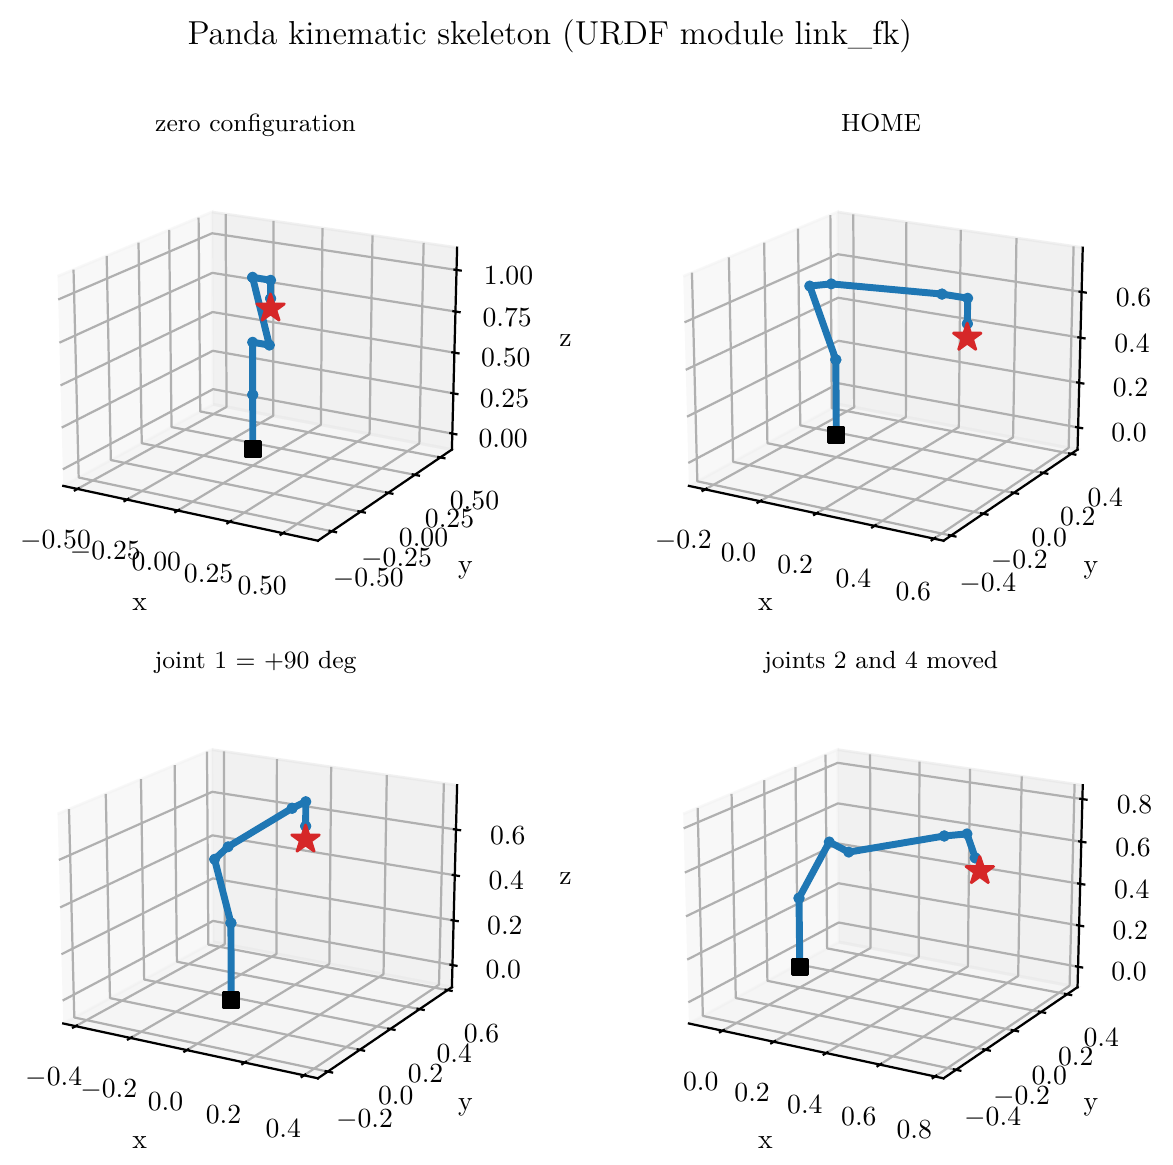

In [10]:
plt = setup_pgf()

def _equal3d(ax, P, pad=0.1):
    lo, hi = P.min(0) - pad, P.max(0) + pad
    c = (lo + hi) / 2; r = (hi - lo).max() / 2
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)

poses = [
    (np.zeros(N_JOINTS), "zero configuration"),
    (HOME, "HOME"),
    (np.array([np.pi/2, -0.3, 0.0, -2.0, 0.0, 1.7, 0.785]), "joint 1 = +90 deg"),
    (np.array([0.0, 0.4, 0.0, -1.0, 0.0, 1.7, 0.785]), "joints 2 and 4 moved"),
]

fig = plt.figure(figsize=(7.4, 6.4))
for k, (q, title) in enumerate(poses, 1):
    ax = fig.add_subplot(2, 2, k, projection="3d")
    P = link_points(q)
    ax.plot(P[:, 0], P[:, 1], P[:, 2], "-o", color="tab:blue", lw=2.5, ms=3)
    ax.scatter(*P[0], color="black", marker="s", s=30)            # base
    ee = sm.forward_kinematics(q)[:3, 3]
    ax.scatter(*ee, color="tab:red", marker="*", s=110)           # end-effector (FK)
    _equal3d(ax, np.vstack([P, ee]))
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.view_init(elev=18, azim=-60)
fig.suptitle("Panda kinematic skeleton (URDF module link_fk)")
embed_pgf_fig(fig, name="panda_skeleton_montage")

## Smoke test

Asserts the key invariants of this notebook in one cell.

In [11]:
M = np.array(sm.M_list)
# Home configuration is FK at zero.
assert np.allclose(sm.forward_kinematics(np.zeros(N_JOINTS)), M)
# Hand-built PoE equals forward_kinematics.
S = np.array(sm.S_list)[:, :N_JOINTS]
T = np.eye(4)
for i in range(N_JOINTS):
    T = T @ MatrixExp6(VecTose3(S[:, i] * HOME[i]))
T = T @ M
assert np.allclose(T, sm.forward_kinematics(HOME, frame='space'))
# Space and body forms agree.
assert np.allclose(sm.forward_kinematics(HOME, frame='space'),
                   sm.forward_kinematics(HOME, frame='body'))
# Every FK output is a valid SE(3) element.
Tt = sm.forward_kinematics(HOME)
assert np.allclose(Tt[3], [0, 0, 0, 1]) and np.isclose(np.linalg.det(Tt[:3, :3]), 1.0)
print("nb02 forward kinematics: smoke OK")

nb02 forward kinematics: smoke OK


## Try it

1. Compute the end-effector pose at $\theta=0$ and read off its height ($z$-coordinate). What physical configuration is this?
2. Move only joint 4 by $-\pi/2$ from `HOME` and report how far (in metres) the end-effector moves.
3. Re-derive the body-form PoE by hand (pre-multiply $M$, use `sm.B_list`) and confirm it equals `forward_kinematics(..., frame='body')`.

*Next up — notebook 03: differentiating FK to get the **Jacobian**, velocity mapping, and the Panda's 7-DOF redundancy.*

## References

1. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — Chapter 4, *Forward Kinematics* (Product of Exponentials, space and body forms).
2. R. M. Murray, Z. Li, and S. S. Sastry, *A Mathematical Introduction to Robotic Manipulation*, CRC Press, 1994. — Origin of the product-of-exponentials formula.
3. B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*, Springer, 2009.
4. ManipulaPy documentation — https://manipulapy.readthedocs.io/ · source — https://github.com/boelnasr/ManipulaPy
